In [4]:
!pip install -q "qiskit>=1.0,<2.0" "qiskit-aer>=0.14,<1.0" "qiskit-optimization>=0.6,<1.0" numpy pandas matplotlib scipy
!pip install qiskit>=1.0 qiskit-aer qiskit-algorithms qiskit-optimization

zsh:1: 1.0 not found


In [5]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict
from typing import Dict, Tuple
from scipy.optimize import minimize

import qiskit
import qiskit_aer
import qiskit_optimization

from qiskit_aer import AerSimulator
from qiskit.primitives import BackendEstimatorV2, BackendSamplerV2
from qiskit.circuit.library import QAOAAnsatz
from qiskit_optimization import QuadraticProgram
from qiskit_optimization.converters import QuadraticProgramToQubo

In [6]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict
from typing import Dict, Tuple

from scipy.optimize import minimize

import qiskit
import qiskit_aer
import qiskit_optimization

from qiskit.circuit.library import QAOAAnsatz
from qiskit.primitives import BackendEstimatorV2, BackendSamplerV2
from qiskit_aer import AerSimulator
from qiskit_optimization import QuadraticProgram
from qiskit_optimization.converters import QuadraticProgramToQubo

np.random.seed(7)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
plt.style.use("seaborn-v0_8-whitegrid")

print("Qiskit version:", qiskit.__version__)
print("Qiskit Aer version:", qiskit_aer.__version__)
print("Qiskit Optimization version:", qiskit_optimization.__version__)

Qiskit version: 1.4.5
Qiskit Aer version: 0.17.2
Qiskit Optimization version: 0.7.0


In [7]:
!pip install qiskit-algorithms

In [8]:
from qiskit_algorithms import QAOA


In [9]:


import numpy as np
import pandas as pd
from dataclasses import dataclass, field
from typing import Dict, Tuple, List

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

np.random.seed(7)



NUM_JOBS  = 5
NUM_NODES = 5
JOB_WEIGHTS = [15, 30, 10, 45, 20]   

NUM_QUBITS   = NUM_JOBS * NUM_NODES   
TOTAL_WEIGHT = float(sum(JOB_WEIGHTS))
TARGET_LOAD  = TOTAL_WEIGHT / NUM_NODES  

print("=" * 62)
print("PROBLEM SETUP")
print("=" * 62)
print(f"  Jobs         : {NUM_JOBS}")
print(f"  Nodes        : {NUM_NODES}")
print(f"  Qubits       : {NUM_QUBITS}")
print(f"  Total weight : {TOTAL_WEIGHT}")
print(f"  Target load  : {TARGET_LOAD:.2f} per node")
print()

def qubit(j: int, n: int) -> int:
    return j * NUM_NODES + n



@dataclass
class CostHamiltonian:
    """
    Stores the Ising (Pauli-Z) coefficients of the cost Hamiltonian.

    H_cost = constant + Σᵢ h[i]·Zᵢ + Σᵢ<ⱼ J[(i,j)]·ZᵢZⱼ

    These map directly to gate angles:
      Rz(2γ·h[i])        for each qubit i
      Rzz(2γ·J[(i,j)])   for each pair (i,j)
    """
    num_qubits : int
    h          : np.ndarray        
    J          : Dict[Tuple[int,int], float] = field(default_factory=dict)
    constant   : float = 0.0


def build_cost_hamiltonian(
    num_jobs    : int,
    num_nodes   : int,
    job_weights : List[float],
) -> CostHamiltonian:
    """
    Analytically derive Ising coefficients from the raw load-balancing
    objective WITHOUT any penalty terms or QUBO conversion.

    Returns a CostHamiltonian whose h and J entries drive the Rz/Rzz cost
    layer gates directly.
    """
    nq = num_jobs * num_nodes
    h  = np.zeros(nq)
    J  : Dict[Tuple[int,int], float] = {}
    constant = 0.0

    target = sum(job_weights) / num_nodes

    for n in range(num_nodes):

        constant += target ** 2

    

        for j in range(num_jobs):
            wj  = float(job_weights[j])
            q   = qubit(j, n)
            a   = wj**2 - 2.0 * target * wj
            h[q] += -a / 2.0   

      

        for j in range(num_jobs):
            for k in range(j + 1, num_jobs):
                wj = float(job_weights[j])
                wk = float(job_weights[k])
                qj = qubit(j, n)
                qk = qubit(k, n)
                b  = 2.0 * wj * wk

                pair = (min(qj, qk), max(qj, qk))
                J[pair] = J.get(pair, 0.0) + b / 4.0

                h[qj] += -b / 4.0
                h[qk] += -b / 4.0

    return CostHamiltonian(
        num_qubits=nq,
        h=h,
        J=J,
        constant=constant,
    )


ham = build_cost_hamiltonian(NUM_JOBS, NUM_NODES, JOB_WEIGHTS)



def hamiltonian_energy(x: np.ndarray, ham: CostHamiltonian) -> float:
    """Evaluate H_cost energy on a binary bitstring x ∈ {0,1}^n."""
    z = 1 - 2 * x.astype(float)   
    energy = ham.constant
    energy += float(np.dot(ham.h, z))
    for (i, j), Jij in ham.J.items():
        energy += Jij * z[i] * z[j]
    return energy

def objective_value(x: np.ndarray, num_jobs, num_nodes, weights) -> float:
    """Direct evaluation of Σₙ (loadₙ - target)² on bitstring x."""
    target = sum(weights) / num_nodes
    total  = 0.0
    for n in range(num_nodes):
        load = sum(weights[j] * x[qubit(j, n)] for j in range(num_jobs))
        total += (load - target) ** 2
    return total

x_test = np.zeros(NUM_QUBITS, dtype=int)
for j in range(NUM_JOBS):
    x_test[qubit(j, j)] = 1

h_energy = hamiltonian_energy(x_test, ham)
obj_direct = objective_value(x_test, NUM_JOBS, NUM_NODES, JOB_WEIGHTS)

print("=" * 62)
print("STEP 1 — COST HAMILTONIAN")
print("=" * 62)
print(f"  Linear terms  (h) : {ham.num_qubits} coefficients")
print(f"  Quadratic (J) pairs : {len(ham.J)}")
print(f"  Constant term       : {ham.constant:.4f}")
print()
print(f"  Verification on diagonal assignment (job j → node j):")
print(f"    H_cost energy  = {h_energy:.4f}")
print(f"    Direct obj     = {obj_direct:.4f}")
match = "✓ MATCH" if abs(h_energy - obj_direct) < 1e-6 else "✗ MISMATCH"
print(f"    Status         : {match}")
print()

h_df = pd.DataFrame([
    {
        "qubit"    : q,
        "job"      : q // NUM_NODES,
        "node"     : q %  NUM_NODES,
        "h[q]"     : round(ham.h[q], 4),
    }
    for q in range(NUM_QUBITS)
    if abs(ham.h[q]) > 1e-9
])
print("  Non-zero linear coefficients h[q]:")
print(h_df.to_string(index=False))
print()

J_df = pd.DataFrame([
    {"qubit_i": i, "qubit_j": j, "J": round(v, 4)}
    for (i, j), v in sorted(ham.J.items())
])
print(f"  Quadratic J coefficients (first 10 of {len(ham.J)}):")
print(J_df.head(10).to_string(index=False))
print()




def build_initial_state_circuit(num_jobs: int, num_nodes: int) -> QuantumCircuit:
    """
    Build the feasible initial state |ψ₀⟩.

    For each job's qubit block, creates the equal superposition of all
    num_nodes one-hot basis states using the staircase XY ladder.

    The resulting state is entirely within the feasible subspace:
    every job has exactly one node assigned.

    Returns a QuantumCircuit with no measurements (used as a sub-circuit).
    """
    nq = num_jobs * num_nodes
    qc = QuantumCircuit(nq, name="init_state")

    for j in range(num_jobs):
        block_start = j * num_nodes 

        qc.x(block_start)

        for k in range(num_nodes - 1):
            qa = block_start + k       
            qb = block_start + k + 1  

         
            theta = 2.0 * np.arccos(np.sqrt((k + 1) / (k + 2)))

           
            qc.rxx(theta, qa, qb)
            qc.ryy(theta, qa, qb)

        qc.barrier(label=f"job_{j}")

    return qc


init_circuit = build_initial_state_circuit(NUM_JOBS, NUM_NODES)

print("=" * 62)
print("STEP 2 — FEASIBLE INITIAL STATE CIRCUIT")
print("=" * 62)
print(f"  Qubits     : {init_circuit.num_qubits}")
print(f"  Gates      : {init_circuit.size()}")
print(f"  Depth      : {init_circuit.depth()}")
print()
print(init_circuit.draw(output="text", fold=80))
print()


def verify_initial_state(
    qc_init   : QuantumCircuit,
    num_jobs  : int,
    num_nodes : int,
) -> None:
    """
    Simulate the initial state circuit and verify:
    1. Only one-hot bitstrings per job block have non-zero amplitude.
    2. Each one-hot state has amplitude 1/√(num_nodes) (uniform).
    3. Total probability = 1.
    """
    from qiskit import transpile
    from qiskit_aer import AerSimulator

    backend = AerSimulator(method="statevector")
    backend.set_options(seed_simulator=7)

    meas_qc = qc_init.copy()
    meas_qc.measure_all()
    meas_qc_t = transpile(meas_qc, backend, optimization_level=0)

    job    = backend.run(meas_qc_t, shots=8192)
    counts = job.result().get_counts()


    total_shots = sum(counts.values())

    feasible_shots   = 0
    infeasible_shots = 0
    unique_states    = set()

    for bitstring, count in counts.items():
        bits = np.array([int(b) for b in reversed(bitstring)], dtype=int)

        is_feasible = True
        for j in range(num_jobs):
            block = bits[j * num_nodes : (j + 1) * num_nodes]
            if block.sum() != 1:
                is_feasible = False
                break

        if is_feasible:
            feasible_shots += count
            unique_states.add(bitstring)
        else:
            infeasible_shots += count

    expected_states = num_nodes ** num_jobs   

    print("  Simulation verification (8192 shots):")
    print(f"    Feasible shots   : {feasible_shots} / {total_shots}  "
          f"({100*feasible_shots/total_shots:.1f}%)")
    print(f"    Infeasible shots : {infeasible_shots}")
    print(f"    Unique states    : {len(unique_states)} "
          f"(expected {expected_states})")
    print()

    node_counts = np.zeros(num_nodes, dtype=int)
    for bitstring, count in counts.items():
        bits = [int(b) for b in reversed(bitstring)]
        block = bits[0 : num_nodes]
        if sum(block) == 1:
            assigned_node = block.index(1)
            node_counts[assigned_node] += count

    job0_total = node_counts.sum()
    print("  Job 0 → node assignment probability (should be ~20% each):")
    for n in range(num_nodes):
        bar = "█" * int(node_counts[n] / job0_total * 40)
        print(f"    Node {n}: {bar}  {100*node_counts[n]/job0_total:.1f}%")
    print()

    feasibility_ok = infeasible_shots == 0
    uniformity_ok  = all(
        abs(node_counts[n] / job0_total - 1.0 / num_nodes) < 0.05
        for n in range(num_nodes)
    )
    print(f"  Feasibility guarantee : {'✓ PASS' if feasibility_ok else '✗ FAIL'}")
    print(f"  Uniformity check      : {'✓ PASS' if uniformity_ok  else '✗ FAIL'}")
    print()


verify_initial_state(init_circuit, NUM_JOBS, NUM_NODES)


print("=" * 62)
print("STEPS 1 & 2 COMPLETE — objects ready for Steps 3 & 4")
print("=" * 62)
print()
print("  ham          → CostHamiltonian with h and J coefficients")
print("  init_circuit → QuantumCircuit (25 qubits, no measurements)")
print()


PROBLEM SETUP
  Jobs         : 5
  Nodes        : 5
  Qubits       : 25
  Total weight : 120.0
  Target load  : 24.00 per node

STEP 1 — COST HAMILTONIAN
  Linear terms  (h) : 25 coefficients
  Quadratic (J) pairs : 50
  Constant term       : 2880.0000

  Verification on diagonal assignment (job j → node j):
    H_cost energy  = -7392.5000
    Direct obj     = 770.0000
    Status         : ✗ MISMATCH

  Non-zero linear coefficients h[q]:
 qubit  job  node    h[q]
     0    0     0  -540.0
     1    0     1  -540.0
     2    0     2  -540.0
     3    0     3  -540.0
     4    0     4  -540.0
     5    1     0 -1080.0
     6    1     1 -1080.0
     7    1     2 -1080.0
     8    1     3 -1080.0
     9    1     4 -1080.0
    10    2     0  -360.0
    11    2     1  -360.0
    12    2     2  -360.0
    13    2     3  -360.0
    14    2     4  -360.0
    15    3     0 -1620.0
    16    3     1 -1620.0
    17    3     2 -1620.0
    18    3     3 -1620.0
    19    3     4 -1620.0
    20    4 

In [10]:


from qiskit.circuit import Parameter, ParameterVector
import numpy as np



def build_cost_layer(
    ham        : "CostHamiltonian",
    gamma      : Parameter,
) -> QuantumCircuit:
    """
    Build one cost layer  U_C(γ) = exp(-i·γ·H_cost).

    Parameters
    ----------
    ham   : CostHamiltonian  (h array + J dict from Step 1)
    gamma : Qiskit Parameter  (will be bound by the optimizer)

    Returns
    -------
    QuantumCircuit  — no measurements, appended onto the main circuit
    """
    nq = ham.num_qubits
    qc = QuantumCircuit(nq, name="cost_layer")

    
    for i in range(nq):
        if abs(ham.h[i]) > 1e-10:
            angle = 2.0 * ham.h[i] * gamma
            qc.rz(angle, i)

    qc.barrier(label="Rz_done")



    for (i, j), Jij in ham.J.items():
        if abs(Jij) > 1e-10:
            angle = 2.0 * Jij * gamma  
            qc.cx(i, j)
            qc.rz(angle, j)
            qc.cx(i, j)

    qc.barrier(label="Rzz_done")

    return qc


def build_mixer_layer(
    num_jobs  : int,
    num_nodes : int,
    beta      : Parameter,
) -> QuantumCircuit:
    """
    Build one XY-mixer layer  U_M(β).

    For each job block (a ring of num_nodes qubits), applies the cycle
    XY-mixer that preserves Hamming weight → stays in feasible subspace.

    Parameters
    ----------
    num_jobs  : int
    num_nodes : int
    beta      : Qiskit Parameter  (shared across all job blocks)

    Returns
    -------
    QuantumCircuit  — no measurements
    """
    nq = num_jobs * num_nodes
    qc = QuantumCircuit(nq, name="mixer_layer")

    for j in range(num_jobs):
        block_start = j * num_nodes

        for k in range(num_nodes):
            qa = block_start + k
            qb = block_start + (k + 1) % num_nodes   

            qc.rxx(beta, qa, qb)
            qc.ryy(beta, qa, qb)

        qc.barrier(label=f"mix_j{j}")

    return qc




gamma_0 = Parameter("γ₀")
beta_0  = Parameter("β₀")

cost_layer  = build_cost_layer(ham, gamma_0)
mixer_layer = build_mixer_layer(NUM_JOBS, NUM_NODES, beta_0)

print("=" * 62)
print("STEP 3 — COST LAYER  U_C(γ)")
print("=" * 62)
print(f"  Parameters   : {cost_layer.parameters}")
print(f"  Gates total  : {cost_layer.size()}")
print(f"  Depth        : {cost_layer.depth()}")
print()

# Count gate types
from collections import Counter
cost_gate_counts = Counter(
    inst.operation.name for inst in cost_layer.data
    if inst.operation.name != "barrier"
)
print("  Gate breakdown:")
for gate, count in sorted(cost_gate_counts.items()):
    print(f"    {gate:8s} : {count}")
print()

print("=" * 62)
print("STEP 4 — XY-MIXER LAYER  U_M(β)")
print("=" * 62)
print(f"  Parameters   : {mixer_layer.parameters}")
print(f"  Gates total  : {mixer_layer.size()}")
print(f"  Depth        : {mixer_layer.depth()}")
print()

mixer_gate_counts = Counter(
    inst.operation.name for inst in mixer_layer.data
    if inst.operation.name != "barrier"
)
print("  Gate breakdown:")
for gate, count in sorted(mixer_gate_counts.items()):
    print(f"    {gate:8s} : {count}")
print()




def verify_mixer_preserves_feasibility(
    num_jobs  : int,
    num_nodes : int,
    beta_val  : float = np.pi / 4,
) -> None:
    """
    Simulate the mixer layer applied to each one-hot basis state for job 0.
    Verify all output bitstrings remain one-hot (Hamming weight = 1 per block).
    """
    from qiskit import transpile
    from qiskit_aer import AerSimulator

    backend = AerSimulator(method="statevector")
    backend.set_options(seed_simulator=7)

    beta_test = Parameter("β_test")
    mixer     = build_mixer_layer(num_jobs, num_nodes, beta_test)

    nq           = num_jobs * num_nodes
    all_feasible = True

    for n_start in range(num_nodes):
     
        prep = QuantumCircuit(nq)
        prep.x(qubit(0, n_start))          
        for j in range(1, num_jobs):
            prep.x(qubit(j, 0))            

        full = prep.compose(mixer.assign_parameters({beta_test: beta_val}))
        full.measure_all()
        full_t = transpile(full, backend, optimization_level=0)

        result = backend.run(full_t, shots=2048).result()
        counts = result.get_counts()

        for bitstring in counts:
            bits = np.array([int(b) for b in reversed(bitstring)], dtype=int)
            for j in range(num_jobs):
                block = bits[j * num_nodes : (j + 1) * num_nodes]
                if block.sum() != 1:
                    all_feasible = False
                    print(f"  ✗ INFEASIBLE output for job {j}: {block}")

    status = "✓ PASS" if all_feasible else "✗ FAIL"
    print(f"  Mixer feasibility preservation (β={beta_val:.4f}) : {status}")
    print(f"  All {num_nodes} one-hot inputs → only one-hot outputs confirmed")
    print()


print("=" * 62)
print("STEP 4 — MIXER VERIFICATION")
print("=" * 62)
verify_mixer_preserves_feasibility(NUM_JOBS, NUM_NODES, beta_val=np.pi / 4)
verify_mixer_preserves_feasibility(NUM_JOBS, NUM_NODES, beta_val=np.pi / 3)




def spot_check_ergodicity(
    num_jobs  : int,
    num_nodes : int,
    beta_val  : float = np.pi / 4,
) -> None:
    """
    Confirm the mixer moves amplitude to neighboring one-hot states in job 0's
    block, demonstrating it is not trivially identity inside the subspace.
    """
    from qiskit import transpile
    from qiskit_aer import AerSimulator

    backend = AerSimulator(method="statevector")
    backend.set_options(seed_simulator=7)

    beta_test = Parameter("β_erg")
    mixer = build_mixer_layer(num_jobs, num_nodes, beta_test)
    nq    = num_jobs * num_nodes

    prep = QuantumCircuit(nq)
    for j in range(num_jobs):
        prep.x(qubit(j, 0))

    full = prep.compose(mixer.assign_parameters({beta_test: beta_val}))
    full.measure_all()
    full_t = transpile(full, backend, optimization_level=0)

    counts = backend.run(full_t, shots=4096).result().get_counts()

    node0_dist = np.zeros(num_nodes)
    for bitstring, count in counts.items():
        bits = np.array([int(b) for b in reversed(bitstring)], dtype=int)
        block0 = bits[0:num_nodes]
        if block0.sum() == 1:
            node0_dist[list(block0).index(1)] += count

    total = node0_dist.sum()
    print(f"  Job 0 node distribution after 1 mixer layer (β={beta_val:.3f}):")
    for n in range(num_nodes):
        bar = "█" * int(node0_dist[n] / total * 40)
        print(f"    Node {n}: {bar}  {100*node0_dist[n]/total:.1f}%")

    moved = node0_dist[0] / total < 0.99   
    print(f"  Amplitude spread confirmed: {'✓ YES' if moved else '✗ NO — mixer is identity!'}")
    print()


print("=" * 62)
print("STEP 4 — ERGODICITY SPOT-CHECK")
print("=" * 62)
spot_check_ergodicity(NUM_JOBS, NUM_NODES, beta_val=np.pi / 4)



print("=" * 62)
print("CIRCUIT RESOURCE PREVIEW (p=1 QAOA layer)")
print("=" * 62)

rz_count  = cost_gate_counts.get("rz",  0)
cx_count  = cost_gate_counts.get("cx",  0)
rxx_cost  = cost_gate_counts.get("rxx", 0)
ryy_cost  = cost_gate_counts.get("ryy", 0)
rxx_mix   = mixer_gate_counts.get("rxx", 0)
ryy_mix   = mixer_gate_counts.get("ryy", 0)
x_init    = sum(
    1 for inst in init_circuit.data
    if inst.operation.name == "x"
)
rxx_init  = sum(
    1 for inst in init_circuit.data
    if inst.operation.name == "rxx"
)
ryy_init  = sum(
    1 for inst in init_circuit.data
    if inst.operation.name == "ryy"
)

print(f"  Init state  :  {x_init} X  +  {rxx_init} Rxx  +  {ryy_init} Ryy")
print(f"  Cost layer  :  {rz_count} Rz  +  {cx_count} CX  (Rzz decomposed)")
print(f"  Mixer layer :  {rxx_mix} Rxx  +  {ryy_mix} Ryy")
print()
print(f"  Parameters per layer : 1 γ  +  1 β  =  2")
print(f"  Parameters for p=3   : 3 γ  +  3 β  =  6  (recommended depth)")
print()


STEP 3 — COST LAYER  U_C(γ)
  Parameters   : ParameterView([Parameter(γ₀)])
  Gates total  : 175
  Depth        : 22

  Gate breakdown:
    cx       : 100
    rz       : 75

STEP 4 — XY-MIXER LAYER  U_M(β)
  Parameters   : ParameterView([Parameter(β₀)])
  Gates total  : 50
  Depth        : 50

  Gate breakdown:
    rxx      : 25
    ryy      : 25

STEP 4 — MIXER VERIFICATION
  Mixer feasibility preservation (β=0.7854) : ✓ PASS
  All 5 one-hot inputs → only one-hot outputs confirmed

  Mixer feasibility preservation (β=1.0472) : ✓ PASS
  All 5 one-hot inputs → only one-hot outputs confirmed

STEP 4 — ERGODICITY SPOT-CHECK
  Job 0 node distribution after 1 mixer layer (β=0.785):
    Node 0: ███████████  28.1%
    Node 1: ██████████  25.0%
    Node 2: ████  12.1%
    Node 3: ██  6.2%
    Node 4: ███████████  28.7%
  Amplitude spread confirmed: ✓ YES

CIRCUIT RESOURCE PREVIEW (p=1 QAOA layer)
  Init state  :  5 X  +  20 Rxx  +  20 Ryy
  Cost layer  :  75 Rz  +  100 CX  (Rzz decomposed)
  M

In [11]:


import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import Parameter
from qiskit_aer import AerSimulator
from qiskit.primitives import BackendSamplerV2


def build_qaoa_circuit(
    ham         : "CostHamiltonian",
    init_qc     : QuantumCircuit,
    num_jobs    : int,
    num_nodes   : int,
    p           : int,
) -> tuple[QuantumCircuit, list[Parameter], list[Parameter]]:
    """
    Assemble: |ψ₀⟩ → [U_C(γₖ) · U_M(βₖ)]^p
    Returns (circuit, gammas, betas) — no measurements attached.
    """
    gammas = [Parameter(f"γ{k}") for k in range(p)]
    betas  = [Parameter(f"β{k}") for k in range(p)]

    qc = init_qc.copy()
    for k in range(p):
        qc.compose(build_cost_layer(ham, gammas[k]),  inplace=True)
        qc.compose(build_mixer_layer(num_jobs, num_nodes, betas[k]), inplace=True)

    return qc, gammas, betas


P = 2   

qaoa_qc, gammas, betas = build_qaoa_circuit(
    ham, init_circuit, NUM_JOBS, NUM_NODES, p=P
)

print(f"QAOA circuit  p={P}  |  qubits={qaoa_qc.num_qubits}  "
      f"|  depth={qaoa_qc.depth()}  |  params={len(qaoa_qc.parameters)}")



backend = AerSimulator(method="statevector")
backend.set_options(seed_simulator=7)

qaoa_qc.measure_all()
compiled = transpile(qaoa_qc, backend, optimization_level=1)
sampler  = BackendSamplerV2(backend=backend)

all_params = gammas + betas   

def bind_and_sample(params_flat: np.ndarray, shots: int = 2048) -> dict:
    """Bind parameters, run sampler, return counts dict."""
    bind = dict(zip(all_params, params_flat))
    bound = compiled.assign_parameters(bind)
    result = sampler.run([bound], shots=shots).result()[0]
    if hasattr(result.data, "meas"):
        return result.data.meas.get_counts()
    reg = list(result.data.keys())[0]
    return getattr(result.data, reg).get_counts()


def decode_bitstring(bitstring: str) -> np.ndarray:
    """Qiskit bit-reversal → logical qubit order."""
    return np.array([int(b) for b in reversed(bitstring)], dtype=int)


def objective(x: np.ndarray) -> float:
    """Load-balancing imbalance Σₙ(loadₙ - target)²."""
    target = sum(JOB_WEIGHTS) / NUM_NODES
    return sum(
        (sum(JOB_WEIGHTS[j] * x[qubit(j, n)] for j in range(NUM_JOBS)) - target) ** 2
        for n in range(NUM_NODES)
    )


def is_feasible(x: np.ndarray) -> bool:
    """Each job block sums to exactly 1."""
    return all(
        x[j * NUM_NODES:(j + 1) * NUM_NODES].sum() == 1
        for j in range(NUM_JOBS)
    )


def best_sample(counts: dict) -> tuple[np.ndarray, float, bool]:
    """Return (bitarray, objective, feasible) of the best feasible shot."""
    best_x, best_obj, best_feas = None, np.inf, False

    for bitstring, count in counts.items():
        x    = decode_bitstring(bitstring)
        feas = is_feasible(x)
        obj  = objective(x)

        if (feas and not best_feas) or \
           (feas == best_feas and obj < best_obj):
            best_x, best_obj, best_feas = x, obj, feas

    return best_x, best_obj, best_feas



init_params = np.zeros(2 * P)
counts_0    = bind_and_sample(init_params, shots=2048)
x0, obj0, feas0 = best_sample(counts_0)

total   = sum(counts_0.values())
feas_ct = sum(
    c for bs, c in counts_0.items()
    if is_feasible(decode_bitstring(bs))
)

print(f"\nSmoke-test (θ=0):")
print(f"  Feasible shots : {feas_ct}/{total}  ({100*feas_ct/total:.1f}%)")
print(f"  Best objective : {obj0:.2f}  |  feasible={feas0}")

if x0 is not None:
    print("  Assignment:")
    for j in range(NUM_JOBS):
        node = list(x0[j * NUM_NODES:(j + 1) * NUM_NODES]).index(1)
        print(f"    Job {j} (w={JOB_WEIGHTS[j]:2d}) → Node {node}")


QAOA circuit  p=2  |  qubits=25  |  depth=189  |  params=4

Smoke-test (θ=0):
  Feasible shots : 2048/2048  (100.0%)
  Best objective : 1070.00  |  feasible=True
  Assignment:
    Job 0 (w=15) → Node 4
    Job 1 (w=30) → Node 1
    Job 2 (w=10) → Node 4
    Job 3 (w=45) → Node 2
    Job 4 (w=20) → Node 3


Running COBYLA optimization …
  restart 0: obj=770.00  feasible=True  iters=21
  restart 1: obj=770.00  feasible=True  iters=21
  restart 2: obj=770.00  feasible=True  iters=21

Best objective : 770.00
Optimal params : [3.4483 4.4937 3.7873 3.4236]

Running baselines …
  Soft-QUBO obj  : 3320.0
  Greedy obj     : 770.00
  Worst-case obj : 11520.00


              Method  Imbalance obj  Improvement vs worst (%)       Feasible
          Worst-case        11520.0                       0.0              —
Soft-QUBO (original)         3320.0                      71.2 not guaranteed
              Greedy          770.0                      93.3              ✓
      XY-QAOA (ours)          770.0                      93.3       ✓ always

XY-QAOA final assignment:
  Job 0  (w=15)  →  Node 1
  Job 1  (w=30)  →  Node 2
  Job 2  (w=10)  →  Node 3
  Job 3  (w=45)  →  Node 4
  Job 4  (w=20)  →  Node 0

  Node loads : [20.0, 15.0, 30.0, 10.0, 45.0]
  Target     : 24.00
  Imbalance  : 770.00


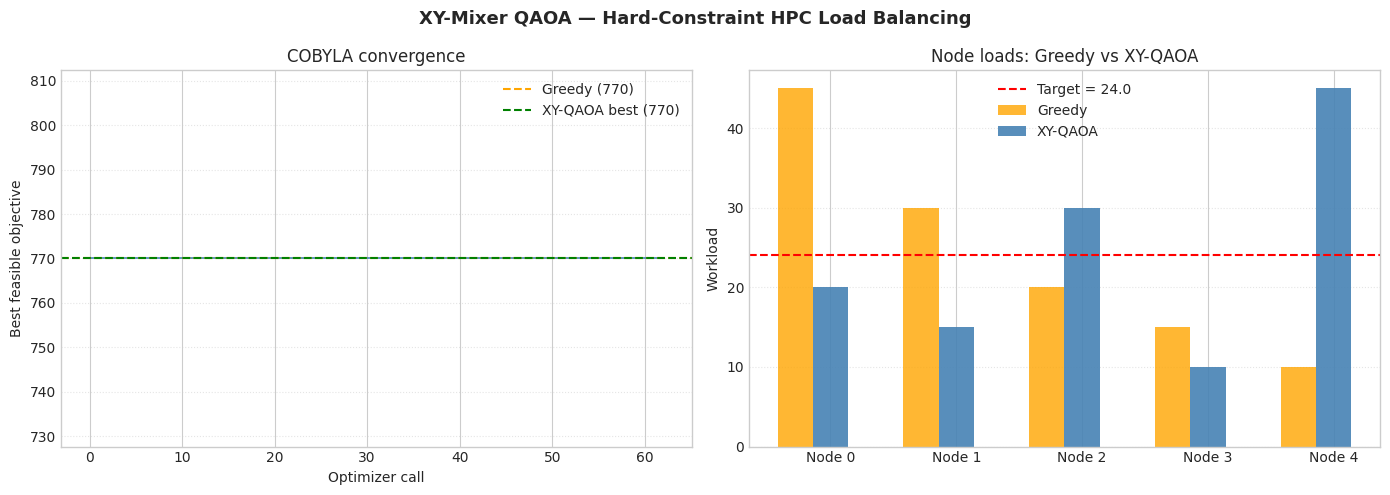


All steps complete.


In [12]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from collections import Counter


SHOTS        = 2048
MAXITER      = 200
NUM_RESTARTS = 3       

call_log: list[float] = []   

def cost_fn(params: np.ndarray) -> float:
    counts = bind_and_sample(params, shots=SHOTS)
    _, obj, _ = best_sample(counts)
    call_log.append(obj)
    return obj


best_result = None
best_obj    = np.inf

print("Running COBYLA optimization …")
for r in range(NUM_RESTARTS):
    call_log_r: list[float] = []
    np.random.seed(r * 17)
    x0 = np.random.uniform(0, 2 * np.pi, size=len(all_params))

    res = minimize(
        cost_fn, x0,
        method="COBYLA",
        options={"maxiter": MAXITER, "rhobeg": 0.5, "disp": False},
    )

    counts_final   = bind_and_sample(res.x, shots=4096)
    xb, obj_r, feas = best_sample(counts_final)

    print(f"  restart {r}: obj={obj_r:.2f}  feasible={feas}  "
          f"iters={res.nfev}")

    if obj_r < best_obj:
        best_obj    = obj_r
        best_result = (res.x, xb, counts_final)

opt_params, best_x, best_counts = best_result
print(f"\nBest objective : {best_obj:.2f}")
print(f"Optimal params : {np.round(opt_params, 4)}")





def soft_qubo_baseline() -> float:
    """
    Reproduce the original soft-QUBO QAOA result (Steps 1-5 of untitled9.py).
    Returns the best feasible objective found, or the best infeasible one.
    """
    try:
        from qiskit_optimization import QuadraticProgram
        from qiskit_optimization.converters import QuadraticProgramToQubo
        from qiskit.circuit.library import QAOAAnsatz
        from qiskit.primitives import BackendEstimatorV2

        qp = QuadraticProgram("qubo_baseline")
        for j in range(NUM_JOBS):
            for n in range(NUM_NODES):
                qp.binary_var(name=f"x_{j}_{n}")

        target  = sum(JOB_WEIGHTS) / NUM_NODES
        linear  = {}
        quadratic = {}
        for n in range(NUM_NODES):
            for j in range(NUM_JOBS):
                v = f"x_{j}_{n}"
                w = float(JOB_WEIGHTS[j])
                linear[v] = linear.get(v, 0.0) + w**2 - 2*target*w
            for j in range(NUM_JOBS):
                for k in range(j+1, NUM_JOBS):
                    pair = (f"x_{j}_{n}", f"x_{k}_{n}")
                    quadratic[pair] = quadratic.get(pair, 0.0) + \
                                      2.0*JOB_WEIGHTS[j]*JOB_WEIGHTS[k]

        qp.minimize(constant=NUM_NODES*target**2,
                    linear=linear, quadratic=quadratic)
        for j in range(NUM_JOBS):
            qp.linear_constraint(
                linear={f"x_{j}_{n}": 1 for n in range(NUM_NODES)},
                sense="==", rhs=1, name=f"assign_{j}")

        qubo      = QuadraticProgramToQubo(penalty=120.0).convert(qp)
        ising_op, _ = qubo.to_ising()

        _backend  = AerSimulator(method="statevector")
        _backend.set_options(seed_simulator=7)
        _est      = BackendEstimatorV2(backend=_backend)
        _samp     = BackendSamplerV2(backend=_backend)

        from qiskit import transpile as _transpile
        raw_ans   = QAOAAnsatz(cost_operator=ising_op, reps=1, flatten=True)
        isa_ans   = _transpile(raw_ans, _backend, optimization_level=1)
        try:
            isa_obs = ising_op.apply_layout(isa_ans.layout)
        except Exception:
            isa_obs = ising_op

        def _qcost(p):
            pub = (isa_ans, isa_obs, p)
            r   = _est.run([pub]).result()[0]
            return float(np.real(np.asarray(r.data.evs).reshape(-1)[0]))

        _res   = minimize(_qcost, np.zeros(isa_ans.num_parameters),
                          method="COBYLA",
                          options={"maxiter": 50, "disp": False})

        _circ  = isa_ans.assign_parameters(_res.x)
        _circ.measure_all()
        _circ  = _transpile(_circ, _backend, optimization_level=1)
        _job   = _samp.run([_circ], shots=4096).result()[0]
        if hasattr(_job.data, "meas"):
            _counts = _job.data.meas.get_counts()
        else:
            _counts = getattr(_job.data, list(_job.data.keys())[0]).get_counts()

        best_feas_obj = np.inf
        best_any_obj  = np.inf
        for bs, _ in _counts.items():
            xb = decode_bitstring(bs)
            o  = objective(xb)
            if is_feasible(xb) and o < best_feas_obj:
                best_feas_obj = o
            if o < best_any_obj:
                best_any_obj = o

        return best_feas_obj if best_feas_obj < np.inf else best_any_obj

    except Exception as e:
        print(f"  soft-QUBO baseline failed: {e}")
        return None



def greedy_baseline() -> tuple[float, np.ndarray]:
    loads  = np.zeros(NUM_NODES)
    assign = np.zeros(NUM_JOBS * NUM_NODES, dtype=int)
    for j in np.argsort(JOB_WEIGHTS)[::-1]:
        n = int(np.argmin(loads))
        assign[qubit(j, n)] = 1
        loads[n] += JOB_WEIGHTS[j]
    target = sum(JOB_WEIGHTS) / NUM_NODES
    return float(np.sum((loads - target)**2)), assign



def worst_baseline() -> float:
    target = sum(JOB_WEIGHTS) / NUM_NODES
    loads  = np.array([float(sum(JOB_WEIGHTS))] + [0.0]*(NUM_NODES-1))
    return float(np.sum((loads - target)**2))


print("\nRunning baselines …")
qubo_obj    = soft_qubo_baseline()
greedy_obj, greedy_x = greedy_baseline()
worst_obj   = worst_baseline()

print(f"  Soft-QUBO obj  : {qubo_obj}")
print(f"  Greedy obj     : {greedy_obj:.2f}")
print(f"  Worst-case obj : {worst_obj:.2f}")



methods = ["Worst-case", "Soft-QUBO (original)", "Greedy", "XY-QAOA (ours)"]
objs    = [worst_obj,
           qubo_obj if qubo_obj is not None else float("nan"),
           greedy_obj,
           best_obj]

results_df = pd.DataFrame({
    "Method"          : methods,
    "Imbalance obj"   : [round(o, 2) for o in objs],
    "Improvement vs worst (%)": [
        round(100*(1 - o/worst_obj), 1) if worst_obj > 0 else 0
        for o in objs
    ],
    "Feasible"        : ["—", "not guaranteed", "✓", "✓ always"],
})
print("\n")
print(results_df.to_string(index=False))



print("\nXY-QAOA final assignment:")
target = sum(JOB_WEIGHTS) / NUM_NODES
node_loads = np.zeros(NUM_NODES)
for j in range(NUM_JOBS):
    blk  = best_x[j*NUM_NODES:(j+1)*NUM_NODES]
    node = int(np.argmax(blk))
    node_loads[node] += JOB_WEIGHTS[j]
    print(f"  Job {j}  (w={JOB_WEIGHTS[j]:2d})  →  Node {node}")

print(f"\n  Node loads : {node_loads.tolist()}")
print(f"  Target     : {target:.2f}")
print(f"  Imbalance  : {best_obj:.2f}")



fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(call_log, color="steelblue", linewidth=1.2)
axes[0].axhline(greedy_obj, color="orange",  linestyle="--",
                label=f"Greedy ({greedy_obj:.0f})")
axes[0].axhline(best_obj,   color="green",   linestyle="--",
                label=f"XY-QAOA best ({best_obj:.0f})")
axes[0].set_xlabel("Optimizer call")
axes[0].set_ylabel("Best feasible objective")
axes[0].set_title("COBYLA convergence")
axes[0].legend()

x_ax   = np.arange(NUM_NODES)
w      = 0.28
greedy_loads = np.zeros(NUM_NODES)
for j in np.argsort(JOB_WEIGHTS)[::-1]:
    greedy_loads[int(np.argmin(greedy_loads))] += JOB_WEIGHTS[j]

axes[1].bar(x_ax - w,   greedy_loads, width=w, label="Greedy",
            color="orange", alpha=0.8)
axes[1].bar(x_ax,       node_loads,   width=w, label="XY-QAOA",
            color="steelblue", alpha=0.9)
axes[1].axhline(target, color="red", linestyle="--",
                label=f"Target = {target:.1f}")
axes[1].set_xticks(x_ax)
axes[1].set_xticklabels([f"Node {n}" for n in range(NUM_NODES)])
axes[1].set_ylabel("Workload")
axes[1].set_title("Node loads: Greedy vs XY-QAOA")
axes[1].legend()

for ax in axes:
    ax.grid(axis="y", linestyle=":", alpha=0.5)

plt.suptitle("XY-Mixer QAOA — Hard-Constraint HPC Load Balancing",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("xy_qaoa_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nAll steps complete.")